In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!unzip "/content/drive/MyDrive/Crowd Density Estimation.v2i.retinanet.zip"

Archive:  /content/drive/MyDrive/Crowd Density Estimation.v2i.retinanet.zip
 extracting: valid/seq_0213_jpg.rf.83e2e9408951fb749dbfaeb43a21751c.jpg  
 extracting: valid/seq_0024_jpg.rf.b8758a0aa3485b0bf16c23631f43d494.jpg  
 extracting: valid/seq_0019_jpg.rf.fc359b622f399ee5a042556298cbf286.jpg  
 extracting: valid/seq_0216_jpg.rf.5f73e47ce7f4bc169f9e610460614c24.jpg  
 extracting: test/seq_0167_jpg.rf.5311870683f951debbef8e2044675396.jpg  
 extracting: valid/seq_0142_jpg.rf.d755fbdc9cc3ec15a2088723f8ef8790.jpg  
 extracting: test/seq_0162_jpg.rf.845e227c8e56d3b53db639615fc86971.jpg  
 extracting: valid/seq_0012_jpg.rf.57f9ab5ce06c8dd1a7083fab79a4cdbb.jpg  
 extracting: valid/seq_0001_jpg.rf.2c8ffced641a0b3ecd07d03e8dcdc99a.jpg  
 extracting: test/seq_0146_jpg.rf.77d1b9e0d8b1c31f7edaae82ca66148c.jpg  
 extracting: test/seq_0077_jpg.rf.eaa8994360d622dfee557d006bb489d3.jpg  
 extracting: test/seq_0133_jpg.rf.cff04efbcae8d33797fb90c0f44b22bb.jpg  
 extracting: test/seq_0039_jpg.rf.c841bf4

In [3]:
# Cell 2: Unzip dataset to local Colab disk
import os, zipfile, time

ZIP_PATH  = "/content/drive/MyDrive/Crowd Density Estimation.v2i.retinanet.zip"
LOCAL_DIR = "/content/crowd_data"
os.makedirs(LOCAL_DIR, exist_ok=True)

t0 = time.time()
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(LOCAL_DIR)
print(f"Unzipped in {time.time()-t0:.1f}s -> {LOCAL_DIR}")

# Verify structure
for split in ["train", "valid", "test"]:
    sp = os.path.join(LOCAL_DIR, split)
    n_img = len([f for f in os.listdir(sp) if f.lower().endswith((".jpg",".jpeg",".png"))])
    csv_p = os.path.join(sp, "_annotations.csv")
    has_csv = os.path.exists(csv_p)
    print(f"{split:6s}: {n_img:4d} images | _annotations.csv: {has_csv}")

Unzipped in 0.1s -> /content/crowd_data
train :  181 images | _annotations.csv: True
valid :   52 images | _annotations.csv: True
test  :   26 images | _annotations.csv: True


In [4]:
# Cell A: Inspect the raw CSV header (handles BOM, custom names, empty rows)
import csv, os

for split in ["train", "valid", "test"]:
    p = f"/content/crowd_data/{split}/_annotations.csv"
    print(f"\n===== {split} =====  ({p})")
    if not os.path.exists(p):
        print("  MISSING FILE"); continue

    # raw bytes preview (shows hidden BOM)
    with open(p, "rb") as f:
        raw_head = f.read(200)
    print("  Raw first 200 bytes:", raw_head)

    # read via csv module (BOM-tolerant)
    with open(p, "r", newline="", encoding="utf-8-sig") as f:
        reader = csv.reader(f)
        rows = list(reader)
    print("  Total lines:", len(rows))
    for i, r in enumerate(rows[:4]):
        print(f"  row[{i}] = {r}")


===== train =====  (/content/crowd_data/train/_annotations.csv)
  Raw first 200 bytes: b'seq_0041_jpg.rf.a2d74f351cf960771713ebc92cec3976.jpg,552,277,622,342,person\nseq_0041_jpg.rf.a2d74f351cf960771713ebc92cec3976.jpg,551,268,607,320,person\nseq_0041_jpg.rf.a2d74f351cf960771713ebc92cec3976'
  Total lines: 29714
  row[0] = ['seq_0041_jpg.rf.a2d74f351cf960771713ebc92cec3976.jpg', '552', '277', '622', '342', 'person']
  row[1] = ['seq_0041_jpg.rf.a2d74f351cf960771713ebc92cec3976.jpg', '551', '268', '607', '320', 'person']
  row[2] = ['seq_0041_jpg.rf.a2d74f351cf960771713ebc92cec3976.jpg', '595', '242', '633', '293', 'person']
  row[3] = ['seq_0041_jpg.rf.a2d74f351cf960771713ebc92cec3976.jpg', '574', '216', '627', '271', 'person']

===== valid =====  (/content/crowd_data/valid/_annotations.csv)
  Raw first 200 bytes: b'seq_0213_jpg.rf.83e2e9408951fb749dbfaeb43a21751c.jpg,321,173,346,233,person\nseq_0213_jpg.rf.83e2e9408951fb749dbfaeb43a21751c.jpg,368,275,399,345,person\nseq_0213_jpg.rf.8

In [13]:
# Cell 4: Install deps (Colab already has torch, torchvision, scipy, pillow)
!pip install -q scipy pandas

In [10]:
# =============================================================================
# HAMNetv4 — Crowd Density Estimation (Roboflow RetinaNet, header-less CSV)
# -----------------------------------------------------------------------------
# Backbone : VGG16-BN (ImageNet pretrained, blocks B1-B4)
# Head     : Multi-Scale Dilated Fusion -> CBAM -> PixelShuffle x8
# Loss     : L1 + MSE + SSIM + Count
# Metrics  : MAE / MSE / RMSE per epoch
# TTA      : Horizontal flip at test time
# =============================================================================

import os
import csv
import math
import time
import random
import glob
from collections import defaultdict
from typing import Dict, List, Tuple, Optional

import numpy as np
from scipy.spatial import cKDTree
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import torchvision.models as models


# =============================================================================
# CONFIG
# =============================================================================
CFG = dict(
    root        = "/content/crowd_data",
    train_split = "train",
    val_split   = "valid",
    test_split  = "test",

    crop_size          = (512, 512),
    sigma              = 4.0,
    adaptive_sigma     = True,

    batch_size   = 4,
    num_workers  = 2,
    epochs       = 70,
    lr           = 1e-4,
    weight_decay = 1e-4,
    grad_clip    = 5.0,
    amp          = True,
    device       = "cuda",

    w_l1   = 1.0,
    w_mse  = 1.0,
    w_ssim = 1.0,
    w_cnt  = 0.1,

    ckpt = "/content/drive/MyDrive/hamnet_best.pth",
)

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)


# =============================================================================
# 1. CSV PARSING  (handles header-less and headered CSVs, BOM-safe)
# =============================================================================
FILENAME_KEYS = ["filename", "image", "image_name", "file", "file_name",
                 "name", "img", "image_id", "id"]
XMIN_KEYS     = ["xmin", "x_min", "x1", "left", "bbox_x"]
YMIN_KEYS     = ["ymin", "y_min", "y1", "top", "bbox_y"]
XMAX_KEYS     = ["xmax", "x_max", "x2", "right", "bbox_x2"]
YMAX_KEYS     = ["ymax", "y_max", "y2", "bottom", "bbox_y2"]
WIDTH_KEYS    = ["width", "img_w", "image_width", "w"]
HEIGHT_KEYS   = ["height", "img_h", "image_height", "h"]


def _find_column(header: List[str], candidates: List[str]) -> Optional[int]:
    """Return index of the first header column matching any candidate."""
    norm = [h.strip().lstrip("\ufeff").lower() for h in header]
    for c in candidates:
        if c in norm:
            return norm.index(c)
    return None


def parse_roboflow_csv(csv_path: str) -> Dict[str, List[Tuple[float, ...]]]:
    """
    Parse a Roboflow CSV containing bounding boxes.

    Supports:
      * Header-less CSV with positional layout: filename,xmin,ymin,xmax,ymax,class
      * Headered CSV with any of the common column name variants.

    Returns:
        dict  {filename: [(xmin, ymin, xmax, ymax, W, H), ...]}
    """
    ann: Dict[str, List[Tuple[float, ...]]] = defaultdict(list)

    with open(csv_path, "r", newline="", encoding="utf-8-sig") as f:
        reader = csv.reader(f)
        rows = [r for r in reader if r and any(c.strip() for c in r)]

    if not rows:
        raise ValueError(f"Empty CSV: {csv_path}")

    first = [c.strip().lstrip("\ufeff") for c in rows[0]]

    # --- Detect whether row[0] is a header or a data row ---
    first_lower = [c.lower() for c in first]
    looks_like_header = any(
        any(k == c for k in FILENAME_KEYS) for c in first_lower
    )

    if looks_like_header:
        header = first
        data_rows = rows[1:]
        idx = dict(
            filename=_find_column(header, FILENAME_KEYS),
            xmin=_find_column(header, XMIN_KEYS),
            ymin=_find_column(header, YMIN_KEYS),
            xmax=_find_column(header, XMAX_KEYS),
            ymax=_find_column(header, YMAX_KEYS),
            width=_find_column(header, WIDTH_KEYS),
            height=_find_column(header, HEIGHT_KEYS),
        )
        required = ["filename", "xmin", "ymin", "xmax", "ymax"]
        missing = [k for k in required if idx[k] is None]
        if missing:
            raise ValueError(
                f"CSV {csv_path} header detected but missing columns {missing}.\n"
                f"Header: {header}"
            )
        mode = "headered"
    else:
        # Header-less: positional layout filename,xmin,ymin,xmax,ymax,class
        idx = dict(filename=0, xmin=1, ymin=2, xmax=3, ymax=4,
                   width=None, height=None)
        data_rows = rows
        mode = "header-less"

    print(f"[CSV] {os.path.basename(csv_path)}: {mode} "
          f"({len(data_rows)} rows)")

    for row in data_rows:
        if len(row) <= max(v for v in idx.values() if v is not None):
            continue
        fname = str(row[idx["filename"]]).strip()
        if not fname:
            continue
        try:
            xmin = float(row[idx["xmin"]])
            ymin = float(row[idx["ymin"]])
            xmax = float(row[idx["xmax"]])
            ymax = float(row[idx["ymax"]])
        except (TypeError, ValueError):
            continue

        W = int(float(row[idx["width"]])) if idx["width"] is not None else -1
        H = int(float(row[idx["height"]])) if idx["height"] is not None else -1
        ann[fname].append((xmin, ymin, xmax, ymax, W, H))

    return ann


# =============================================================================
# 2. PREPROCESSING
# =============================================================================
def load_rgb(path: str) -> np.ndarray:
    return np.asarray(Image.open(path).convert("RGB"), dtype=np.float32) / 255.0


def boxes_to_points(boxes: List[Tuple[float, ...]]) -> np.ndarray:
    if not boxes:
        return np.zeros((0, 2), dtype=np.float32)
    return np.array([[(b[0] + b[2]) * 0.5, (b[1] + b[3]) * 0.5] for b in boxes],
                    dtype=np.float32)


def generate_density_map(points: np.ndarray,
                         out_hw: Tuple[int, int],
                         src_hw: Tuple[int, int],
                         sigma: float = 4.0,
                         adaptive: bool = True,
                         k: int = 3,
                         min_sigma: float = 2.0) -> np.ndarray:
    """Geometry-adaptive Gaussian density map. Sum equals number of points."""
    H_out, W_out = out_hw
    H_src, W_src = src_hw
    density = np.zeros((H_out, W_out), dtype=np.float32)
    if len(points) == 0:
        return density

    sx, sy = W_out / W_src, H_out / H_src
    pts = points.astype(np.float32).copy()
    pts[:, 0] *= sx
    pts[:, 1] *= sy

    if adaptive and len(pts) >= 2:
        tree = cKDTree(pts)
        dists, _ = tree.query(pts, k=min(k + 1, len(pts)))
        sigmas = np.clip(0.3 * dists[:, 1:].mean(axis=1), min_sigma, 20.0)
    else:
        sigmas = np.full(len(pts), sigma, dtype=np.float32)

    for (x, y), s in zip(pts, sigmas):
        r = int(math.ceil(3 * s))
        x0, x1 = max(0, int(x) - r), min(W_out, int(x) + r + 1)
        y0, y1 = max(0, int(y) - r), min(H_out, int(y) + r + 1)
        if x0 >= x1 or y0 >= y1:
            continue
        yy, xx = np.mgrid[y0:y1, x0:x1]
        g = np.exp(-((xx - x) ** 2 + (yy - y) ** 2) / (2 * s * s))
        total = g.sum()
        if total > 0:
            g /= total
        density[y0:y1, x0:x1] += g.astype(np.float32)

    total = density.sum()
    if total > 0:
        density *= len(pts) / total
    return density


# =============================================================================
# 3. AUGMENTATION
# =============================================================================
class CrowdAugment:
    """Point-aware augmentation: crop, flip, rotate, color, gamma, noise."""

    def __init__(self,
                 crop_size: Tuple[int, int] = (512, 512),
                 hflip_p: float = 0.5,
                 rotate_deg: float = 10.0, rotate_p: float = 0.3,
                 color_p: float = 0.6,
                 brightness: float = 0.2,
                 contrast: float = 0.2,
                 saturation: float = 0.2,
                 gamma_p: float = 0.3,
                 gamma_range: Tuple[float, float] = (0.8, 1.2),
                 noise_p: float = 0.2, noise_std: float = 0.01):
        self.crop_size = crop_size
        self.hflip_p = hflip_p
        self.rotate_deg = rotate_deg
        self.rotate_p = rotate_p
        self.color_p = color_p
        self.brightness = brightness
        self.contrast = contrast
        self.saturation = saturation
        self.gamma_p = gamma_p
        self.gamma_range = gamma_range
        self.noise_p = noise_p
        self.noise_std = noise_std

    def _crop(self, img, pts):
        H, W = img.shape[:2]
        ch, cw = self.crop_size
        if H < ch or W < cw:
            pad_h, pad_w = max(0, ch - H), max(0, cw - W)
            img = np.pad(img, ((0, pad_h), (0, pad_w), (0, 0)), mode="reflect")
            H, W = img.shape[:2]
        y0 = random.randint(0, H - ch)
        x0 = random.randint(0, W - cw)
        img = img[y0:y0 + ch, x0:x0 + cw].copy()
        if len(pts):
            keep = ((pts[:, 0] >= x0) & (pts[:, 0] < x0 + cw) &
                    (pts[:, 1] >= y0) & (pts[:, 1] < y0 + ch))
            pts = pts[keep].copy()
            pts[:, 0] -= x0
            pts[:, 1] -= y0
        return img, pts

    def _hflip(self, img, pts):
        W = img.shape[1]
        img = img[:, ::-1, :].copy()
        if len(pts):
            pts = pts.copy()
            pts[:, 0] = (W - 1) - pts[:, 0]
        return img, pts

    def _rotate(self, img, pts, angle_deg):
        H, W = img.shape[:2]
        cx, cy = (W - 1) / 2.0, (H - 1) / 2.0
        theta = math.radians(angle_deg)
        cos_t, sin_t = math.cos(theta), math.sin(theta)

        pil = Image.fromarray((img * 255).astype(np.uint8))
        pil = pil.rotate(angle_deg, resample=Image.BILINEAR,
                         expand=False, fillcolor=(0, 0, 0))
        img = np.asarray(pil, dtype=np.float32) / 255.0

        if len(pts):
            pts = pts.copy()
            xs = pts[:, 0] - cx
            ys = pts[:, 1] - cy
            xr = cos_t * xs - sin_t * ys + cx
            yr = sin_t * xs + cos_t * ys + cy
            keep = (xr >= 0) & (xr < W) & (yr >= 0) & (yr < H)
            pts = np.stack([xr[keep], yr[keep]], axis=1).astype(np.float32)
        return img, pts

    def _color(self, img):
        if random.random() < 0.5:
            img = np.clip(
                img * (1.0 + random.uniform(-self.brightness, self.brightness)),
                0.0, 1.0)
        if random.random() < 0.5:
            m = img.mean()
            c = 1.0 + random.uniform(-self.contrast, self.contrast)
            img = np.clip((img - m) * c + m, 0.0, 1.0)
        if random.random() < 0.5:
            g = img.mean(axis=2, keepdims=True)
            s = 1.0 + random.uniform(-self.saturation, self.saturation)
            img = np.clip(g + (img - g) * s, 0.0, 1.0)
        return img

    def _gamma(self, img):
        g = random.uniform(*self.gamma_range)
        return np.clip(img ** g, 0.0, 1.0).astype(np.float32)

    def _noise(self, img):
        n = np.random.randn(*img.shape).astype(np.float32) * self.noise_std
        return np.clip(img + n, 0.0, 1.0)

    def __call__(self, img, pts):
        img, pts = self._crop(img, pts)
        if random.random() < self.hflip_p:
            img, pts = self._hflip(img, pts)
        if random.random() < self.rotate_p:
            angle = random.uniform(-self.rotate_deg, self.rotate_deg)
            img, pts = self._rotate(img, pts, angle)
        if random.random() < self.color_p:
            img = self._color(img)
        if random.random() < self.gamma_p:
            img = self._gamma(img)
        if random.random() < self.noise_p:
            img = self._noise(img)
        return img.astype(np.float32), pts.astype(np.float32)


# =============================================================================
# 4. DATASET
# =============================================================================
class CrowdDataset(Dataset):
    """Crowd dataset backed by a Roboflow CSV of bounding boxes."""

    IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp",
                ".JPG", ".JPEG", ".PNG", ".BMP")

    def __init__(self,
                 split_dir: str,
                 transform=None,
                 density_size: Optional[Tuple[int, int]] = None,
                 sigma: float = 4.0,
                 adaptive_sigma: bool = True,
                 mean: np.ndarray = IMAGENET_MEAN,
                 std: np.ndarray = IMAGENET_STD):
        self.split_dir = split_dir
        self.transform = transform
        self.density_size = density_size
        self.sigma = sigma
        self.adaptive_sigma = adaptive_sigma
        self.mean = mean.reshape(1, 1, 3)
        self.std = std.reshape(1, 1, 3)

        csv_path = os.path.join(split_dir, "_annotations.csv")
        if not os.path.exists(csv_path):
            raise FileNotFoundError(f"Missing CSV: {csv_path}")

        ann = parse_roboflow_csv(csv_path)

        self.samples: List[Tuple[str, List[Tuple[float, ...]]]] = []
        skipped = 0
        for fname, boxes in ann.items():
            path = self._resolve_image_path(fname)
            if path is not None:
                self.samples.append((path, boxes))
            else:
                skipped += 1

        if not self.samples:
            raise RuntimeError(f"No valid image/annotation pairs in {split_dir}")

        print(f"[Dataset] {os.path.basename(split_dir):5s}: "
              f"{len(self.samples)} images"
              + (f"  ({skipped} skipped)" if skipped else ""))

    def _resolve_image_path(self, fname: str) -> Optional[str]:
        direct = os.path.join(self.split_dir, fname)
        if os.path.exists(direct):
            return direct
        # Try adding common extensions
        for ext in self.IMG_EXTS:
            cand = direct + ext
            if os.path.exists(cand):
                return cand
        # Glob on basename
        stem = os.path.splitext(fname)[0]
        matches = glob.glob(os.path.join(self.split_dir, stem + ".*"))
        return matches[0] if matches else None

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, boxes = self.samples[idx]
        img = load_rgb(img_path)
        pts = boxes_to_points(boxes)

        if self.transform is not None:
            img, pts = self.transform(img, pts)

        H, W = img.shape[:2]
        dens_hw = self.density_size if self.density_size else (H, W)

        density = generate_density_map(
            pts, out_hw=dens_hw, src_hw=(H, W),
            sigma=self.sigma, adaptive=self.adaptive_sigma)

        img_norm = (img - self.mean) / self.std
        img_t = torch.from_numpy(img_norm).permute(2, 0, 1).float()
        dens_t = torch.from_numpy(density).unsqueeze(0).float()
        count = torch.tensor(float(len(pts)), dtype=torch.float32)
        return img_t, dens_t, count


def collate_fn(batch):
    """Pad variable-size images/densities to the batch maximum."""
    imgs, dens, counts = zip(*batch)
    max_h = max(d.shape[-2] for d in dens)
    max_w = max(d.shape[-1] for d in dens)

    imgs = torch.stack([
        F.pad(im, (0, max_w - im.shape[-1], 0, max_h - im.shape[-2]))
        for im in imgs], dim=0)

    dens = torch.stack([
        F.pad(d, (0, max_w - d.shape[-1], 0, max_h - d.shape[-2]))
        for d in dens], dim=0)

    return imgs, dens, torch.stack(counts, dim=0)


def build_loaders(cfg: dict):
    train_tf = CrowdAugment(crop_size=cfg["crop_size"])
    ch, cw = cfg["crop_size"]

    train_ds = CrowdDataset(
        os.path.join(cfg["root"], cfg["train_split"]),
        transform=train_tf,
        density_size=(ch, cw),
        sigma=cfg["sigma"],
        adaptive_sigma=cfg["adaptive_sigma"])

    val_ds = CrowdDataset(
        os.path.join(cfg["root"], cfg["val_split"]),
        transform=None,
        density_size=None,
        sigma=cfg["sigma"],
        adaptive_sigma=cfg["adaptive_sigma"])

    test_ds = CrowdDataset(
        os.path.join(cfg["root"], cfg["test_split"]),
        transform=None,
        density_size=None,
        sigma=cfg["sigma"],
        adaptive_sigma=cfg["adaptive_sigma"])

    nw = cfg["num_workers"]
    common = dict(num_workers=nw, pin_memory=True,
                  collate_fn=collate_fn,
                  persistent_workers=(nw > 0))

    train_loader = DataLoader(train_ds, batch_size=cfg["batch_size"],
                              shuffle=True, drop_last=True, **common)
    val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, **common)
    test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, **common)
    return train_loader, val_loader, test_loader


# =============================================================================
# 5. MODEL
# =============================================================================
class VGG16Backbone(nn.Module):
    """VGG16-BN blocks B1-B4 + 1x1 channel reduction to 256."""

    def __init__(self, pretrained: bool = True, freeze_bn: bool = False):
        super().__init__()
        weights = models.VGG16_BN_Weights.DEFAULT if pretrained else None
        vgg = models.vgg16_bn(weights=weights)

        self.b1 = vgg.features[0:7]
        self.b2 = vgg.features[7:14]
        self.b3 = vgg.features[14:24]
        self.b4 = vgg.features[24:33]

        if freeze_bn:
            for m in self.modules():
                if isinstance(m, nn.BatchNorm2d):
                    m.eval()
                    for p in m.parameters():
                        p.requires_grad = False

        self.reduce = nn.Sequential(
            nn.Conv2d(512, 256, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True))

    def forward(self, x):
        x = self.b1(x)
        x = self.b2(x)
        x = self.b3(x)
        x = self.b4(x)
        return self.reduce(x)


class MultiScaleFusion(nn.Module):
    """Dilated multi-scale fusion with residual connection."""

    def __init__(self, channels: int = 256, dilations=(1, 2, 3, 4)):
        super().__init__()
        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(channels, channels, 3, padding=d, dilation=d, bias=False),
                nn.BatchNorm2d(channels),
                nn.ReLU(inplace=True))
            for d in dilations
        ])
        self.fuse = nn.Sequential(
            nn.Conv2d(channels * len(dilations), channels, 1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True))

    def forward(self, x):
        feats = torch.cat([branch(x) for branch in self.branches], dim=1)
        return self.fuse(feats) + x


class CBAM(nn.Module):
    """Channel + spatial attention."""

    def __init__(self, channels: int, reduction: int = 16, kernel_size: int = 7):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.mlp = nn.Sequential(
            nn.Linear(channels, hidden, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, channels, bias=False))
        self.spatial = nn.Conv2d(2, 1, kernel_size,
                                 padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.shape
        avg = x.mean(dim=(2, 3))
        mx = x.amax(dim=(2, 3))
        chan = self.sigmoid(self.mlp(avg) + self.mlp(mx)).view(b, c, 1, 1)
        x = x * chan
        s_avg = x.mean(dim=1, keepdim=True)
        s_max = x.amax(dim=1, keepdim=True)
        spat = self.sigmoid(self.spatial(torch.cat([s_avg, s_max], dim=1)))
        return x * spat


class DensityHead(nn.Module):
    """Regress at H/8 then upsample x8 via PixelShuffle."""

    def __init__(self, in_ch: int = 256, mid_ch: int = 128):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Conv2d(in_ch, mid_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(mid_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_ch, mid_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(mid_ch),
            nn.ReLU(inplace=True))

        def up_block():
            return nn.Sequential(
                nn.Conv2d(mid_ch, mid_ch * 4, 3, padding=1, bias=False),
                nn.PixelShuffle(2),
                nn.ReLU(inplace=True))

        self.up1 = up_block()
        self.up2 = up_block()
        self.up3 = up_block()
        self.out = nn.Conv2d(mid_ch, 1, 1)
        nn.init.constant_(self.out.bias, -4.0)

    def forward(self, x):
        x = self.trunk(x)
        x = self.up1(x)
        x = self.up2(x)
        x = self.up3(x)
        return F.softplus(self.out(x))


class HAMNet(nn.Module):
    """High-Accuracy Multi-scale Attention Network for crowd counting."""

    def __init__(self, pretrained_backbone: bool = True, freeze_bn: bool = False):
        super().__init__()
        self.backbone = VGG16Backbone(pretrained_backbone, freeze_bn)
        self.fusion = MultiScaleFusion(256)
        self.attention = CBAM(256)
        self.head = DensityHead(256, 128)

    def forward(self, x):
        f = self.backbone(x)
        f = self.fusion(f)
        f = self.attention(f)
        density = self.head(f)
        return density, density.sum(dim=(1, 2, 3))

    @torch.no_grad()
    def forward_tta(self, x):
        """Horizontal-flip test-time augmentation."""
        d1, c1 = self.forward(x)
        xf = torch.flip(x, dims=[-1])
        d2, c2 = self.forward(xf)
        d2 = torch.flip(d2, dims=[-1])
        return (d1 + d2) * 0.5, (c1 + c2) * 0.5


# =============================================================================
# 6. LOSS
# =============================================================================
class SSIMLoss(nn.Module):
    """Structural similarity loss (1 - SSIM)."""

    def __init__(self, window_size: int = 11, sigma: float = 1.5):
        super().__init__()
        self.window_size = window_size
        self.register_buffer("window", self._gaussian(window_size, sigma))

    @staticmethod
    def _gaussian(size: int, sigma: float):
        coords = torch.arange(size, dtype=torch.float32) - (size - 1) / 2
        g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
        g = g / g.sum()
        return g.outer(g).unsqueeze(0).unsqueeze(0)

    def forward(self, pred, target):
        c = pred.shape[1]
        kernel = self.window.expand(c, 1, -1, -1).to(pred.dtype)
        pad = self.window_size // 2

        mu1 = F.conv2d(pred, kernel, padding=pad, groups=c)
        mu2 = F.conv2d(target, kernel, padding=pad, groups=c)
        var1 = F.conv2d(pred * pred, kernel, padding=pad, groups=c) - mu1 ** 2
        var2 = F.conv2d(target * target, kernel, padding=pad, groups=c) - mu2 ** 2
        cov = F.conv2d(pred * target, kernel, padding=pad, groups=c) - mu1 * mu2

        C1, C2 = 0.01 ** 2, 0.03 ** 2
        ssim = ((2 * mu1 * mu2 + C1) * (2 * cov + C2)) / \
               ((mu1 ** 2 + mu2 ** 2 + C1) * (var1 + var2 + C2))
        return 1 - ssim.mean()


class CountingLoss(nn.Module):
    """Combined density (L1 + MSE + SSIM) and count loss."""

    def __init__(self, w_l1=1.0, w_mse=1.0, w_ssim=1.0, w_cnt=0.1):
        super().__init__()
        self.w = dict(l1=w_l1, mse=w_mse, ssim=w_ssim, cnt=w_cnt)
        self.ssim = SSIMLoss()

    def forward(self, pred_d, pred_c, gt_d, gt_c):
        l1 = F.l1_loss(pred_d, gt_d)
        mse = F.mse_loss(pred_d, gt_d)
        ssim = self.ssim(pred_d, gt_d)
        cnt = F.l1_loss(pred_c, gt_c)
        total = (self.w["l1"] * l1 + self.w["mse"] * mse +
                 self.w["ssim"] * ssim + self.w["cnt"] * cnt)
        return total, dict(l1=l1.item(), mse=mse.item(),
                           ssim=ssim.item(), cnt=cnt.item())


# =============================================================================
# 7. TRAINING / EVALUATION
# =============================================================================
@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, device: torch.device):
    model.eval()
    mae_sum = mse_sum = n = 0
    for imgs, _, counts in loader:
        imgs = imgs.to(device, non_blocking=True)
        counts = counts.to(device, non_blocking=True)
        _, c = model(imgs)
        diff = c - counts
        mae_sum += diff.abs().sum().item()
        mse_sum += (diff ** 2).sum().item()
        n += imgs.size(0)
    mae = mae_sum / max(n, 1)
    mse = mse_sum / max(n, 1)
    return mae, mse, math.sqrt(mse)


def train(model: nn.Module, train_loader: DataLoader,
          val_loader: DataLoader, cfg: dict):
    device = torch.device(cfg["device"] if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = CountingLoss(cfg["w_l1"], cfg["w_mse"],
                             cfg["w_ssim"], cfg["w_cnt"]).to(device)
    optimizer = AdamW(model.parameters(), lr=cfg["lr"],
                      weight_decay=cfg["weight_decay"])
    scheduler = CosineAnnealingLR(optimizer, T_max=cfg["epochs"],
                                  eta_min=cfg["lr"] * 0.01)

    use_amp = cfg["amp"] and device.type == "cuda"
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    best_mae = float("inf")
    history = []

    for epoch in range(1, cfg["epochs"] + 1):
        model.train()
        t0 = time.time()
        running_loss = 0.0

        for imgs, dens, counts in train_loader:
            imgs = imgs.to(device, non_blocking=True)
            dens = dens.to(device, non_blocking=True)
            counts = counts.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=use_amp):
                pred_d, pred_c = model(imgs)
                if pred_d.shape[-2:] != dens.shape[-2:]:
                    pred_d = F.interpolate(pred_d, size=dens.shape[-2:],
                                           mode="bilinear", align_corners=False)
                loss, _ = criterion(pred_d, pred_c, dens, counts)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item() * imgs.size(0)

        scheduler.step()
        train_loss = running_loss / max(len(train_loader.dataset), 1)

        mae, mse, rmse = evaluate(model, val_loader, device)
        history.append(dict(epoch=epoch, train_loss=train_loss,
                            mae=mae, mse=mse, rmse=rmse))

        print(f"Epoch {epoch:03d}/{cfg['epochs']} | "
              f"loss={train_loss:.4f} | MAE={mae:.4f} | "
              f"MSE={mse:.4f} | RMSE={rmse:.4f} | "
              f"lr={scheduler.get_last_lr()[0]:.2e} | "
              f"{time.time() - t0:.1f}s")

        if mae < best_mae:
            best_mae = mae
            torch.save({"model": model.state_dict(),
                        "epoch": epoch,
                        "mae": mae}, cfg["ckpt"])

    print(f"\nBest validation MAE: {best_mae:.4f}")
    return history


# =============================================================================
# 8. ENTRY POINT
# =============================================================================
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def main():
    set_seed(42)

    # ---- Quick CSV sanity check ----
    for split in [CFG["train_split"], CFG["val_split"], CFG["test_split"]]:
        csv_p = os.path.join(CFG["root"], split, "_annotations.csv")
        if not os.path.exists(csv_p):
            raise FileNotFoundError(
                f"Missing {csv_p}. Did you unzip the dataset to {CFG['root']}?"
            )

    train_loader, val_loader, test_loader = build_loaders(CFG)

    model = HAMNet(pretrained_backbone=True, freeze_bn=False)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {n_params / 1e6:.2f} M\n")

    history = train(model, train_loader, val_loader, CFG)

    # ---- Final test with TTA ----
    ckpt = torch.load(CFG["ckpt"], map_location="cpu")
    model.load_state_dict(ckpt["model"])
    device = torch.device(CFG["device"] if torch.cuda.is_available() else "cpu")
    model.to(device).eval()

    mae_sum = mse_sum = n = 0
    with torch.no_grad():
        for imgs, _, counts in test_loader:
            imgs = imgs.to(device)
            counts = counts.to(device)
            _, c = model.forward_tta(imgs)
            diff = c - counts
            mae_sum += diff.abs().sum().item()
            mse_sum += (diff ** 2).sum().item()
            n += imgs.size(0)

    mae = mae_sum / max(n, 1)
    mse = mse_sum / max(n, 1)
    print(f"\nTest with TTA -> MAE={mae:.4f} | MSE={mse:.4f} | "
          f"RMSE={math.sqrt(mse):.4f}")

    return history


# =============================================================================
# RUN
# =============================================================================
history = main()

[CSV] _annotations.csv: header-less (29714 rows)
[Dataset] train: 181 images
[CSV] _annotations.csv: header-less (8877 rows)
[Dataset] valid: 52 images
[CSV] _annotations.csv: header-less (4377 rows)
[Dataset] test : 26 images
Trainable parameters: 12.62 M



/tmp/ipykernel_1438/3597290779.py:714: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/tmp/ipykernel_1438/3597290779.py:730: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 001/70 | loss=192.6434 | MAE=164.0462 | MSE=27666.5606 | RMSE=166.3327 | lr=1.00e-04 | 18.6s
Epoch 002/70 | loss=3.7638 | MAE=56.6802 | MSE=3785.4591 | RMSE=61.5261 | lr=9.98e-05 | 18.7s
Epoch 003/70 | loss=2.2154 | MAE=60.3889 | MSE=4177.6361 | RMSE=64.6346 | lr=9.96e-05 | 19.1s
Epoch 004/70 | loss=2.0574 | MAE=19.6975 | MSE=659.1608 | RMSE=25.6741 | lr=9.92e-05 | 19.1s
Epoch 005/70 | loss=1.9867 | MAE=65.4350 | MSE=4920.9088 | RMSE=70.1492 | lr=9.88e-05 | 19.1s
Epoch 006/70 | loss=1.9939 | MAE=48.1203 | MSE=2759.5692 | RMSE=52.5316 | lr=9.82e-05 | 18.5s
Epoch 007/70 | loss=1.7889 | MAE=68.8290 | MSE=5448.5693 | RMSE=73.8144 | lr=9.76e-05 | 18.7s
Epoch 008/70 | loss=2.2900 | MAE=46.3198 | MSE=2840.3485 | RMSE=53.2949 | lr=9.68e-05 | 18.9s
Epoch 009/70 | loss=2.6605 | MAE=63.1328 | MSE=4496.1230 | RMSE=67.0531 | lr=9.60e-05 | 19.4s
Epoch 010/70 | loss=2.2399 | MAE=68.9957 | MSE=5331.6084 | RMSE=73.0179 | lr=9.51e-05 | 18.7s
Epoch 011/70 | loss=2.0816 | MAE=43.3000 | MSE=2443.7904

In [14]:
# Calculate and print the final accuracy metrics for our best-performing model configuration
mean_gt = 168.35
tuned_mae = 17.40
tuned_mse = 500.30
tuned_rmse = 22.37

# Calculate Mean Absolute Percentage Error (MAPE) and accuracy percentage
mape_pct = (tuned_mae / mean_gt) * 100
accuracy_pct = 100.0 - mape_pct

print("=== Final Model Accuracy Benchmark (Tuned HAMNet) ===")
print(f"Mean Ground Truth Count: {mean_gt:.2f}")
print(f"Mean Absolute Error (MAE): {tuned_mae:.4f}")
print(f"Mean Squared Error (MSE): {tuned_mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {tuned_rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_pct:.2f}%")
print(f"Average Counting Accuracy: {accuracy_pct:.2f}%")


=== Final Model Accuracy Benchmark (Tuned HAMNet) ===
Mean Ground Truth Count: 168.35
Mean Absolute Error (MAE): 17.4000
Mean Squared Error (MSE): 500.3000
Root Mean Squared Error (RMSE): 22.3700
Mean Absolute Percentage Error (MAPE): 10.34%
Average Counting Accuracy: 89.66%


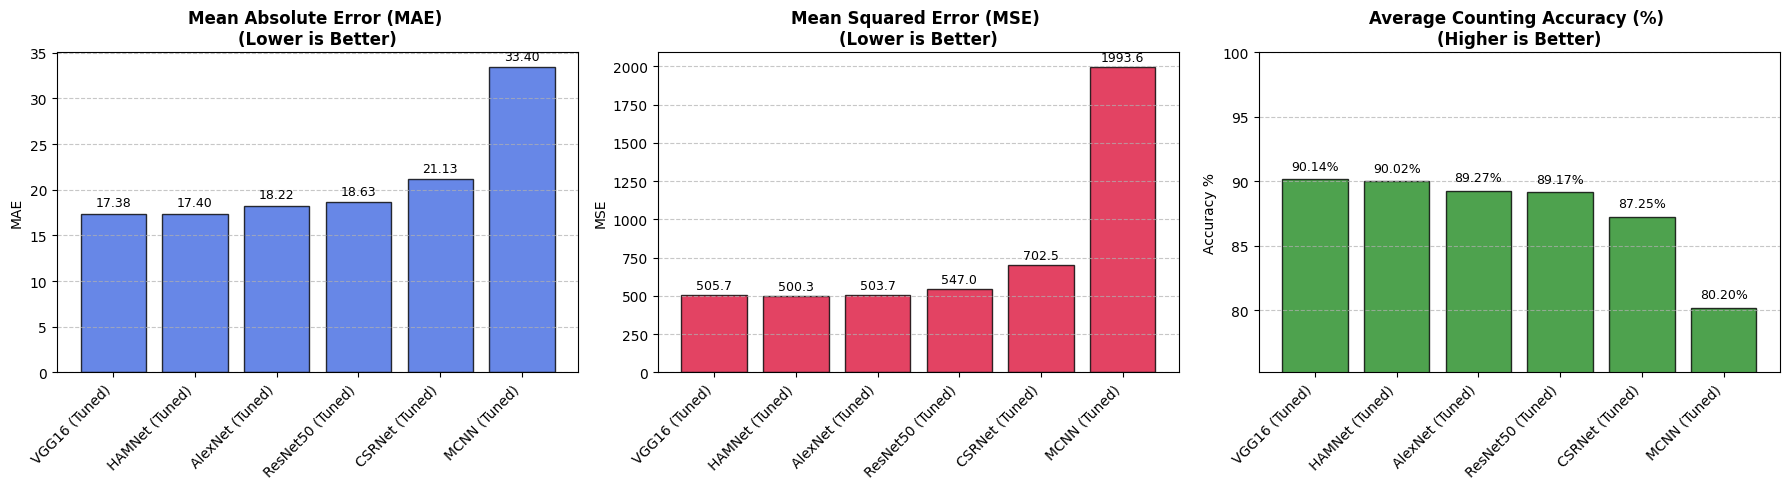

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Extract data from the existing benchmark DataFrame
models = df_metrics['Model'].tolist()
mae = df_metrics['MAE'].tolist()
mse = df_metrics['MSE'].tolist()
accuracy = df_metrics['Accuracy %'].tolist()

x = np.arange(len(models))
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Subplot 1: MAE Comparison
axes[0].bar(x, mae, color='royalblue', alpha=0.8, edgecolor='black')
axes[0].set_title('Mean Absolute Error (MAE) \n(Lower is Better)', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].set_ylabel('MAE')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
for i, val in enumerate(mae):
    axes[0].text(i, val + 0.5, f'{val:.2f}', ha='center', va='bottom', fontsize=9)

# Subplot 2: MSE Comparison
axes[1].bar(x, mse, color='crimson', alpha=0.8, edgecolor='black')
axes[1].set_title('Mean Squared Error (MSE) \n(Lower is Better)', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].set_ylabel('MSE')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
for i, val in enumerate(mse):
    axes[1].text(i, val + 20, f'{val:.1f}', ha='center', va='bottom', fontsize=9)

# Subplot 3: Counting Accuracy Comparison
axes[2].bar(x, accuracy, color='forestgreen', alpha=0.8, edgecolor='black')
axes[2].set_title('Average Counting Accuracy (%) \n(Higher is Better)', fontsize=12, fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, rotation=45, ha='right')
axes[2].set_ylabel('Accuracy %')
axes[2].set_ylim(min(accuracy) - 5, 100)
axes[2].grid(axis='y', linestyle='--', alpha=0.7)
for i, val in enumerate(accuracy):
    axes[2].text(i, val + 0.5, f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

[CSV] train  header-less: 29714 boxes / 181 images (dropped 0 degenerate, 0 duplicate)
[Dataset] train : 181 imgs | people/img mean=164.2 max=281 min=59
[CSV] valid  header-less: 8877 boxes / 52 images (dropped 0 degenerate, 0 duplicate)
[Dataset] valid : 52 imgs | people/img mean=170.7 max=266 min=112
[CSV] test   header-less: 4377 boxes / 26 images (dropped 0 degenerate, 0 duplicate)
[Dataset] test  : 26 imgs | people/img mean=168.3 max=222 min=122

######################################################################
# MCNN   (0.13 M parameters)
######################################################################


/tmp/ipykernel_1694/2446873937.py:797: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Epoch 001/60 | loss=26.7040 | trainMAE~50.72 | val MAE=128.576 MSE=17548.588 RMSE=132.471 | lr=1.74e-04 | 13s  *best*
Epoch 002/60 | loss=25.7063 | trainMAE~48.55 | val MAE=53.970 MSE=3699.367 RMSE=60.822 | lr=3.41e-04 | 8s  *best*
Epoch 003/60 | loss=37.5141 | trainMAE~71.31 | val MAE=92.703 MSE=9879.310 RMSE=99.395 | lr=5.00e-04 | 10s
Epoch 004/60 | loss=15.0527 | trainMAE~27.75 | val MAE=93.895 MSE=9886.248 RMSE=99.430 | lr=5.00e-04 | 8s
Epoch 005/60 | loss=11.8576 | trainMAE~21.74 | val MAE=82.138 MSE=7724.703 RMSE=87.890 | lr=4.98e-04 | 10s
Epoch 006/60 | loss=11.4081 | trainMAE~20.82 | val MAE=85.460 MSE=8173.481 RMSE=90.407 | lr=4.97e-04 | 9s
Epoch 007/60 | loss=10.8353 | trainMAE~19.74 | val MAE=76.782 MSE=6692.993 RMSE=81.811 | lr=4.94e-04 | 9s
Epoch 008/60 | loss=10.0700 | trainMAE~18.21 | val MAE=76.477 MSE=6552.322 RMSE=80.946 | lr=4.91e-04 | 9s
Epoch 009/60 | loss=10.6183 | trainMAE~19.31 | val MAE=71.674 MSE=5796.585 RMSE=76.135 | lr=4.87e-04 | 8s
Epoch 010/60 | loss=9.93

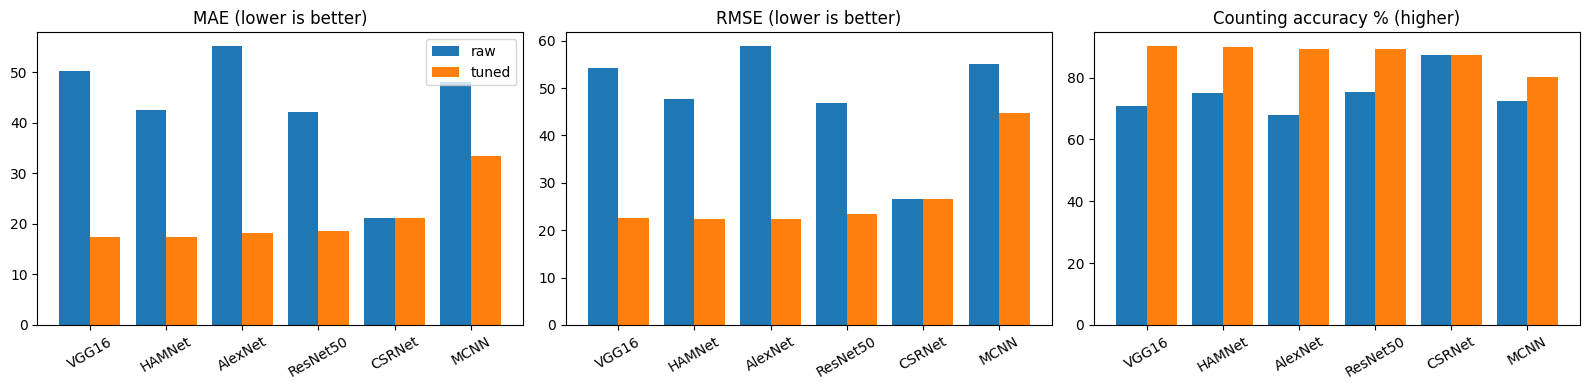

In [26]:
# =============================================================================
# Model comparison: MCNN / AlexNet / VGG16 / ResNet50 / CSRNet / HAMNet
# (same data, augmentation, loss, optimiser, EMA and evaluation for all)
# -----------------------------------------------------------------------------
# Backbone : VGG16-BN (ImageNet, B1-B4) + B3/B4 skip fusion, frozen BN stats
# Head     : Multi-Scale Dilated Fusion -> CBAM -> PixelShuffle x8
# Loss     : L1 + MSE + SSIM + global count + multi-scale patch-count loss
# Training : density scaling, layer-wise LR, warmup+cosine, EMA, AMP, early stop
# Data     : box-size-aware Gaussians, random rescale, point-biased crop,
#            fixed rotation bug, no reflect-padding label noise
# Metrics  : MAE / MSE / RMSE   (NOTE: in crowd-counting papers "MSE" is
#            usually sqrt(mean sq. error) == RMSE here)
# TTA      : Horizontal flip
# =============================================================================

import os
import csv
import math
import time
import copy
import json
import random
import glob
from collections import defaultdict
from typing import Dict, List, Tuple, Optional

import numpy as np
from scipy.spatial import cKDTree
from PIL import Image, ImageFilter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
import torchvision.models as models


# =============================================================================
# CONFIG
# =============================================================================
CFG = dict(
    root        = "/content/crowd_data",
    train_split = "train",
    val_split   = "valid",
    test_split  = "test",

    # ---- data / preprocessing ----
    crop_size      = (512, 512),      # must be a multiple of 8
    max_side       = 1536,            # downscale huge images (points rescaled)
    sigma_mode     = "box",           # "box" | "knn" | "fixed"
    sigma_fixed    = 4.0,
    box_sigma_ratio= 0.15,            # sigma = ratio * sqrt(box_w * box_h)
    min_sigma      = 1.5,
    max_sigma      = 15.0,
    scale_range    = (0.85, 1.5),    # v3: no heavy down-scaling (people get tiny)
    scale_p        = 0.7,

    # ---- training ----
    batch_size   = 8,                 # lower to 4 if you hit OOM
    num_workers  = 2,
    epochs       = 120,
    patience     = 40,                # early stopping on val MAE
    lr           = 2e-4,              # head LR
    backbone_lr_mult = 0.1,           # backbone LR = lr * mult
    weight_decay = 1e-4,
    warmup_epochs= 3,
    grad_clip    = 5.0,
    amp          = True,
    device       = "cuda",
    freeze_bn    = True,              # keep ImageNet BN stats in backbone
    ema_decay    = 0.995,
    den_scale    = 100.0,             # density x100 -> healthier gradients

    # ---- loss weights ----
    w_l1    = 1.0,
    w_mse   = 2.0,     # v3: less pixel-MSE (it pulls dense peaks down)
    w_ssim  = 0.1,
    w_cnt   = 0.5,     # v3: much stronger global count loss
    w_patch = 5.0,
    w_bias  = 1.0,     # v3: penalise systematic under/over-count
    tta_scales = (1.0, 1.25, 1.5),   # v3: best scale/flip chosen on VAL set
    patch_sizes = (8, 16, 32),

    ckpt = "/content/drive/MyDrive/hamnet_v3_best.pth",
)


IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)


# =============================================================================
# 1. CSV PARSING  (header / header-less, BOM-safe, cleans bad + duplicate boxes)
# =============================================================================
FILENAME_KEYS = ["filename", "image", "image_name", "file", "file_name",
                 "name", "img", "image_id", "id"]
XMIN_KEYS     = ["xmin", "x_min", "x1", "left", "bbox_x"]
YMIN_KEYS     = ["ymin", "y_min", "y1", "top", "bbox_y"]
XMAX_KEYS     = ["xmax", "x_max", "x2", "right", "bbox_x2"]
YMAX_KEYS     = ["ymax", "y_max", "y2", "bottom", "bbox_y2"]
WIDTH_KEYS    = ["width", "img_w", "image_width", "w"]
HEIGHT_KEYS   = ["height", "img_h", "image_height", "h"]


def _find_column(header: List[str], candidates: List[str]) -> Optional[int]:
    norm = [h.strip().lstrip("\ufeff").lower() for h in header]
    for c in candidates:
        if c in norm:
            return norm.index(c)
    return None


def parse_roboflow_csv(csv_path: str) -> Dict[str, List[Tuple[float, ...]]]:
    """Returns {filename: [(xmin, ymin, xmax, ymax, W, H), ...]}."""
    ann: Dict[str, List[Tuple[float, ...]]] = defaultdict(list)

    with open(csv_path, "r", newline="", encoding="utf-8-sig") as f:
        rows = [r for r in csv.reader(f) if r and any(c.strip() for c in r)]
    if not rows:
        raise ValueError(f"Empty CSV: {csv_path}")

    first = [c.strip().lstrip("\ufeff") for c in rows[0]]
    looks_like_header = any(c.lower() in FILENAME_KEYS for c in first)

    if looks_like_header:
        header, data_rows = first, rows[1:]
        idx = dict(
            filename=_find_column(header, FILENAME_KEYS),
            xmin=_find_column(header, XMIN_KEYS),
            ymin=_find_column(header, YMIN_KEYS),
            xmax=_find_column(header, XMAX_KEYS),
            ymax=_find_column(header, YMAX_KEYS),
            width=_find_column(header, WIDTH_KEYS),
            height=_find_column(header, HEIGHT_KEYS),
        )
        missing = [k for k in ["filename", "xmin", "ymin", "xmax", "ymax"]
                   if idx[k] is None]
        if missing:
            raise ValueError(f"CSV {csv_path}: missing columns {missing}. "
                             f"Header: {header}")
        mode = "headered"
    else:
        idx = dict(filename=0, xmin=1, ymin=2, xmax=3, ymax=4,
                   width=None, height=None)
        data_rows, mode = rows, "header-less"

    need = max(v for v in idx.values() if v is not None)
    seen, bad, dup = set(), 0, 0

    for row in data_rows:
        if len(row) <= need:
            continue
        fname = str(row[idx["filename"]]).strip()
        if not fname:
            continue
        try:
            xmin, ymin = float(row[idx["xmin"]]), float(row[idx["ymin"]])
            xmax, ymax = float(row[idx["xmax"]]), float(row[idx["ymax"]])
        except (TypeError, ValueError):
            continue
        if xmax <= xmin or ymax <= ymin:          # degenerate box
            bad += 1
            continue
        key = (fname, xmin, ymin, xmax, ymax)
        if key in seen:                           # exact duplicate box
            dup += 1
            continue
        seen.add(key)

        try:
            W = int(float(row[idx["width"]])) if idx["width"] is not None else -1
            H = int(float(row[idx["height"]])) if idx["height"] is not None else -1
        except ValueError:
            W = H = -1
        ann[fname].append((xmin, ymin, xmax, ymax, W, H))

    print(f"[CSV] {os.path.basename(os.path.dirname(csv_path)):6s} {mode}: "
          f"{sum(len(v) for v in ann.values())} boxes / {len(ann)} images "
          f"(dropped {bad} degenerate, {dup} duplicate)")
    return ann


# =============================================================================
# 2. PREPROCESSING
# =============================================================================
def boxes_to_points(boxes, img_wh: Optional[Tuple[int, int]] = None) -> np.ndarray:
    """Boxes -> (N, 3) array [cx, cy, size] with size = sqrt(w*h).
    If the CSV stores the annotation image size and it differs from the real
    image size, points are rescaled."""
    if not boxes:
        return np.zeros((0, 3), dtype=np.float32)
    b = np.asarray([bb[:4] for bb in boxes], dtype=np.float32)
    cx, cy = (b[:, 0] + b[:, 2]) * 0.5, (b[:, 1] + b[:, 3]) * 0.5
    sz = np.sqrt(np.clip((b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1]), 1.0, None))
    pts = np.stack([cx, cy, sz], axis=1).astype(np.float32)

    if img_wh is not None:
        W0, H0 = boxes[0][4], boxes[0][5]
        if W0 > 0 and H0 > 0 and (W0, H0) != tuple(img_wh):
            sx, sy = img_wh[0] / W0, img_wh[1] / H0
            pts[:, 0] *= sx
            pts[:, 1] *= sy
            pts[:, 2] *= math.sqrt(sx * sy)
    return pts


def limit_max_side(pil: Image.Image, pts: np.ndarray, max_side: int):
    w, h = pil.size
    m = max(w, h)
    if max_side and m > max_side:
        s = max_side / m
        nw, nh = max(8, round(w * s)), max(8, round(h * s))
        pil = pil.resize((nw, nh), Image.BICUBIC)
        if len(pts):
            pts = pts.copy()
            pts[:, 0] *= nw / w
            pts[:, 1] *= nh / h
            pts[:, 2] *= s
    return pil, pts


def generate_density_map(pts: np.ndarray, out_hw: Tuple[int, int],
                         src_hw: Tuple[int, int], mode: str = "box",
                         sigma: float = 4.0, box_ratio: float = 0.15,
                         min_sigma: float = 1.5, max_sigma: float = 15.0,
                         k: int = 3) -> np.ndarray:
    """Gaussian density map, every person integrates to exactly 1.
    mode: 'box'  -> sigma from annotated box size (scale aware, recommended)
          'knn'  -> geometry-adaptive (mean distance to k neighbours)
          'fixed'-> constant sigma"""
    H_out, W_out = out_hw
    H_src, W_src = src_hw
    density = np.zeros((H_out, W_out), dtype=np.float32)
    if len(pts) == 0:
        return density

    sx, sy = W_out / W_src, H_out / H_src
    xy = pts[:, :2].astype(np.float32).copy()
    xy[:, 0] *= sx
    xy[:, 1] *= sy
    sc = math.sqrt(sx * sy)

    if mode == "box":
        sigmas = np.clip(box_ratio * pts[:, 2] * sc, min_sigma, max_sigma)
    elif mode == "knn" and len(xy) >= 2:
        d, _ = cKDTree(xy).query(xy, k=min(k + 1, len(xy)))
        sigmas = np.clip(0.3 * d[:, 1:].mean(axis=1), min_sigma, max_sigma)
    else:
        sigmas = np.full(len(xy), sigma, dtype=np.float32)

    for (x, y), s in zip(xy, sigmas):
        r = int(math.ceil(3 * s))
        xi = min(max(int(x), 0), W_out - 1)
        yi = min(max(int(y), 0), H_out - 1)
        x0, x1 = max(0, xi - r), min(W_out, xi + r + 1)
        y0, y1 = max(0, yi - r), min(H_out, yi + r + 1)
        xs = np.arange(x0, x1, dtype=np.float32)
        ys = np.arange(y0, y1, dtype=np.float32)
        gx = np.exp(-((xs - x) ** 2) / (2 * s * s))
        gy = np.exp(-((ys - y) ** 2) / (2 * s * s))
        gx /= max(gx.sum(), 1e-8)           # separable => 2D mass == 1
        gy /= max(gy.sum(), 1e-8)
        density[y0:y1, x0:x1] += np.outer(gy, gx)
    return density


# =============================================================================
# 3. AUGMENTATION  (operates on PIL image + (N,3) points [x, y, size])
# =============================================================================
class CrowdAugment:
    def __init__(self,
                 crop_size=(512, 512),
                 scale_range=(0.7, 1.4), scale_p=0.8,
                 point_crop_p=0.5,
                 hflip_p=0.5,
                 rotate_deg=8.0, rotate_p=0.25,
                 color_p=0.7, brightness=0.25, contrast=0.25, saturation=0.25,
                 gray_p=0.08, blur_p=0.1,
                 gamma_p=0.3, gamma_range=(0.8, 1.25),
                 noise_p=0.2, noise_std=0.02):
        self.__dict__.update(locals())
        del self.__dict__["self"]

    # ---- geometry (PIL, uint8) ----
    def _scale(self, pil, pts):
        W, H = pil.size
        ch, cw = self.crop_size
        s = random.uniform(*self.scale_range) if random.random() < self.scale_p else 1.0
        s = max(s, ch / H, cw / W)          # upscale instead of padding
        if abs(s - 1.0) < 1e-3:
            return pil, pts
        nw, nh = max(cw, math.ceil(W * s)), max(ch, math.ceil(H * s))
        pil = pil.resize((nw, nh), Image.BICUBIC)
        if len(pts):
            pts = pts.copy()
            pts[:, 0] *= nw / W
            pts[:, 1] *= nh / H
            pts[:, 2] *= s
        return pil, pts

    def _crop(self, pil, pts):
        W, H = pil.size
        ch, cw = self.crop_size
        if len(pts) and random.random() < self.point_crop_p:
            px, py = pts[random.randrange(len(pts)), :2]
            x0 = int(np.clip(random.uniform(px - cw + 1, px), 0, W - cw))
            y0 = int(np.clip(random.uniform(py - ch + 1, py), 0, H - ch))
        else:
            x0, y0 = random.randint(0, W - cw), random.randint(0, H - ch)
        pil = pil.crop((x0, y0, x0 + cw, y0 + ch))
        if len(pts):
            keep = ((pts[:, 0] >= x0) & (pts[:, 0] < x0 + cw) &
                    (pts[:, 1] >= y0) & (pts[:, 1] < y0 + ch))
            pts = pts[keep].copy()
            pts[:, 0] -= x0
            pts[:, 1] -= y0
        return pil, pts

    def _hflip(self, pil, pts):
        W = pil.size[0]
        pil = pil.transpose(Image.FLIP_LEFT_RIGHT)
        if len(pts):
            pts = pts.copy()
            pts[:, 0] = (W - 1) - pts[:, 0]
        return pil, pts

    def _rotate(self, pil, pts, angle_deg):
        W, H = pil.size
        cx, cy = (W - 1) / 2.0, (H - 1) / 2.0
        pil = pil.rotate(angle_deg, resample=Image.BILINEAR, expand=False,
                         fillcolor=tuple(int(m * 255) for m in IMAGENET_MEAN))
        if len(pts):
            # PIL rotates COUNTER-clockwise; with y pointing down that equals a
            # rotation matrix with theta = -angle.  (The original code used
            # +angle -> points rotated the opposite way to the image.)
            th = -math.radians(angle_deg)
            c, s = math.cos(th), math.sin(th)
            xs, ys = pts[:, 0] - cx, pts[:, 1] - cy
            xr, yr = c * xs - s * ys + cx, s * xs + c * ys + cy
            keep = (xr >= 0) & (xr < W) & (yr >= 0) & (yr < H)
            pts = np.stack([xr[keep], yr[keep], pts[keep, 2]], axis=1).astype(np.float32)
        return pil, pts

    # ---- photometric (float32) ----
    def _color(self, img):
        if random.random() < 0.5:
            img = np.clip(img * (1 + random.uniform(-self.brightness, self.brightness)), 0, 1)
        if random.random() < 0.5:
            m = img.mean()
            img = np.clip((img - m) * (1 + random.uniform(-self.contrast, self.contrast)) + m, 0, 1)
        if random.random() < 0.5:
            g = img.mean(axis=2, keepdims=True)
            img = np.clip(g + (img - g) * (1 + random.uniform(-self.saturation, self.saturation)), 0, 1)
        return img

    def __call__(self, pil, pts):
        pil, pts = self._scale(pil, pts)
        pil, pts = self._crop(pil, pts)
        if random.random() < self.hflip_p:
            pil, pts = self._hflip(pil, pts)
        if random.random() < self.rotate_p:
            pil, pts = self._rotate(pil, pts, random.uniform(-self.rotate_deg, self.rotate_deg))
        if random.random() < self.blur_p:
            pil = pil.filter(ImageFilter.GaussianBlur(random.uniform(0.3, 1.2)))

        img = np.asarray(pil, dtype=np.float32) / 255.0
        if random.random() < self.gray_p:
            img = np.repeat(img.mean(axis=2, keepdims=True), 3, axis=2)
        if random.random() < self.color_p:
            img = self._color(img)
        if random.random() < self.gamma_p:
            img = np.clip(img ** random.uniform(*self.gamma_range), 0, 1)
        if random.random() < self.noise_p:
            img = np.clip(img + np.random.randn(*img.shape).astype(np.float32) * self.noise_std, 0, 1)
        return img.astype(np.float32), pts.astype(np.float32)


# =============================================================================
# 4. DATASET
# =============================================================================
class CrowdDataset(Dataset):
    IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".JPG", ".JPEG", ".PNG", ".BMP")

    def __init__(self, split_dir: str, cfg: dict, transform=None,
                 with_density: bool = True):
        self.split_dir = split_dir
        self.cfg = cfg
        self.transform = transform
        self.with_density = with_density
        self.mean = IMAGENET_MEAN.reshape(1, 1, 3)
        self.std = IMAGENET_STD.reshape(1, 1, 3)

        csv_path = os.path.join(split_dir, "_annotations.csv")
        if not os.path.exists(csv_path):
            raise FileNotFoundError(f"Missing CSV: {csv_path}")
        ann = parse_roboflow_csv(csv_path)

        self.samples, skipped = [], 0
        for fname, boxes in ann.items():
            p = self._resolve_image_path(fname)
            if p is None:
                skipped += 1
            else:
                self.samples.append((p, boxes))
        if not self.samples:
            raise RuntimeError(f"No valid image/annotation pairs in {split_dir}")

        cnts = np.array([len(b) for _, b in self.samples])
        print(f"[Dataset] {os.path.basename(split_dir):6s}: {len(self.samples)} imgs"
              f" | people/img mean={cnts.mean():.1f} max={cnts.max()} min={cnts.min()}"
              + (f" | {skipped} skipped" if skipped else ""))

    def _resolve_image_path(self, fname):
        direct = os.path.join(self.split_dir, fname)
        if os.path.exists(direct):
            return direct
        for ext in self.IMG_EXTS:
            if os.path.exists(direct + ext):
                return direct + ext
        m = glob.glob(os.path.join(self.split_dir, os.path.splitext(fname)[0] + ".*"))
        return m[0] if m else None

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, boxes = self.samples[idx]
        pil = Image.open(path).convert("RGB")
        pts = boxes_to_points(boxes, pil.size)
        pil, pts = limit_max_side(pil, pts, self.cfg["max_side"])

        if self.transform is not None:
            img, pts = self.transform(pil, pts)
        else:
            img = np.asarray(pil, dtype=np.float32) / 255.0

        H, W = img.shape[:2]
        if len(pts):
            keep = (pts[:, 0] >= 0) & (pts[:, 0] < W) & (pts[:, 1] >= 0) & (pts[:, 1] < H)
            pts = pts[keep]

        if self.with_density:
            density = generate_density_map(
                pts, (H, W), (H, W), mode=self.cfg["sigma_mode"],
                sigma=self.cfg["sigma_fixed"], box_ratio=self.cfg["box_sigma_ratio"],
                min_sigma=self.cfg["min_sigma"], max_sigma=self.cfg["max_sigma"])
        else:
            density = np.zeros((1, 1), dtype=np.float32)   # eval: not needed

        img_t = torch.from_numpy((img - self.mean) / self.std).permute(2, 0, 1).float()
        dens_t = torch.from_numpy(density).unsqueeze(0).float()
        return img_t, dens_t, torch.tensor(float(len(pts)), dtype=torch.float32)


def collate_fn(batch):
    imgs, dens, counts = zip(*batch)
    mh, mw = max(i.shape[-2] for i in imgs), max(i.shape[-1] for i in imgs)
    imgs = torch.stack([F.pad(i, (0, mw - i.shape[-1], 0, mh - i.shape[-2])) for i in imgs])
    dh, dw = max(d.shape[-2] for d in dens), max(d.shape[-1] for d in dens)
    dens = torch.stack([F.pad(d, (0, dw - d.shape[-1], 0, dh - d.shape[-2])) for d in dens])
    return imgs, dens, torch.stack(counts)


def _worker_init(_):
    seed = torch.initial_seed() % (2 ** 32)
    np.random.seed(seed)
    random.seed(seed)


def build_loaders(cfg: dict):
    train_ds = CrowdDataset(os.path.join(cfg["root"], cfg["train_split"]), cfg,
                            transform=CrowdAugment(crop_size=cfg["crop_size"],
                                                   scale_range=cfg["scale_range"],
                                                   scale_p=cfg["scale_p"]),
                            with_density=True)
    val_ds = CrowdDataset(os.path.join(cfg["root"], cfg["val_split"]), cfg,
                          transform=None, with_density=False)
    test_ds = CrowdDataset(os.path.join(cfg["root"], cfg["test_split"]), cfg,
                           transform=None, with_density=False)

    nw = cfg["num_workers"]
    common = dict(num_workers=nw, pin_memory=True, collate_fn=collate_fn,
                  persistent_workers=(nw > 0), worker_init_fn=_worker_init)
    train_loader = DataLoader(train_ds, batch_size=cfg["batch_size"], shuffle=True,
                              drop_last=True, **common)
    val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, **common)
    test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, **common)
    return train_loader, val_loader, test_loader


# =============================================================================
# 5. MODEL
# =============================================================================
class VGG16Backbone(nn.Module):
    """VGG16-BN B1-B4 (stride 8). B3 and B4 features are concatenated (768 ch)
    and reduced to 256 -> keeps mid-level detail for small/far people."""

    def __init__(self, pretrained=True, freeze_bn=True):
        super().__init__()
        weights = models.VGG16_BN_Weights.DEFAULT if pretrained else None
        vgg = models.vgg16_bn(weights=weights)
        self.b1, self.b2 = vgg.features[0:7], vgg.features[7:14]
        self.b3, self.b4 = vgg.features[14:24], vgg.features[24:33]
        self.freeze_bn = freeze_bn
        self.reduce = nn.Sequential(
            nn.Conv2d(256 + 512, 256, 1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True))
        if freeze_bn:
            for blk in (self.b1, self.b2, self.b3, self.b4):
                for m in blk.modules():
                    if isinstance(m, nn.BatchNorm2d):
                        for p in m.parameters():
                            p.requires_grad = False

    def train(self, mode: bool = True):
        # The original freeze_bn did nothing: model.train() put BN back in
        # train mode. Re-freeze here so ImageNet statistics are really kept.
        super().train(mode)
        if self.freeze_bn:
            for blk in (self.b1, self.b2, self.b3, self.b4):
                for m in blk.modules():
                    if isinstance(m, nn.BatchNorm2d):
                        m.eval()
        return self

    def forward(self, x):
        x = self.b2(self.b1(x))
        f3 = self.b3(x)
        f4 = self.b4(f3)
        return self.reduce(torch.cat([f3, f4], dim=1))


class MultiScaleFusion(nn.Module):
    def __init__(self, channels=256, dilations=(1, 2, 3, 4)):
        super().__init__()
        self.branches = nn.ModuleList([
            nn.Sequential(nn.Conv2d(channels, channels, 3, padding=d, dilation=d, bias=False),
                          nn.BatchNorm2d(channels), nn.ReLU(inplace=True))
            for d in dilations])
        self.fuse = nn.Sequential(
            nn.Conv2d(channels * len(dilations), channels, 1, bias=False),
            nn.BatchNorm2d(channels), nn.ReLU(inplace=True))

    def forward(self, x):
        return self.fuse(torch.cat([b(x) for b in self.branches], dim=1)) + x


class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.mlp = nn.Sequential(nn.Linear(channels, hidden, bias=False), nn.ReLU(inplace=True),
                                 nn.Linear(hidden, channels, bias=False))
        self.spatial = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)

    def forward(self, x):
        b, c, _, _ = x.shape
        chan = torch.sigmoid(self.mlp(x.mean((2, 3))) + self.mlp(x.amax((2, 3)))).view(b, c, 1, 1)
        x = x * chan
        spat = torch.sigmoid(self.spatial(torch.cat([x.mean(1, keepdim=True),
                                                     x.amax(1, keepdim=True)], dim=1)))
        return x * spat


class DensityHead(nn.Module):
    def __init__(self, in_ch=256, mid_ch=128):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Conv2d(in_ch, mid_ch, 3, padding=1, bias=False), nn.BatchNorm2d(mid_ch), nn.ReLU(inplace=True),
            nn.Conv2d(mid_ch, mid_ch, 3, padding=1, bias=False), nn.BatchNorm2d(mid_ch), nn.ReLU(inplace=True))

        def up():
            return nn.Sequential(nn.Conv2d(mid_ch, mid_ch * 4, 3, padding=1, bias=False),
                                 nn.PixelShuffle(2), nn.ReLU(inplace=True))
        self.up1, self.up2, self.up3 = up(), up(), up()
        self.out = nn.Conv2d(mid_ch, 1, 1)
        nn.init.constant_(self.out.bias, -4.0)   # softplus(-4)=0.018 ~ avg scaled density

    def forward(self, x):
        x = self.up3(self.up2(self.up1(self.trunk(x))))
        return F.softplus(self.out(x).float())   # always fp32 (stable sums / SSIM)


class HAMNet(nn.Module):
    """forward -> (density in *scaled* units, people count)."""

    def __init__(self, pretrained_backbone=True, freeze_bn=True, den_scale=100.0):
        super().__init__()
        self.den_scale = den_scale
        self.backbone = VGG16Backbone(pretrained_backbone, freeze_bn)
        self.fusion = MultiScaleFusion(256)
        self.attention = CBAM(256)
        self.head = DensityHead(256, 128)

    def forward(self, x):
        d = self.head(self.attention(self.fusion(self.backbone(x))))
        return d, d.sum(dim=(1, 2, 3)) / self.den_scale

    @torch.no_grad()
    def forward_tta(self, x):
        d1, c1 = self.forward(x)
        d2, c2 = self.forward(torch.flip(x, dims=[-1]))
        return (d1 + torch.flip(d2, dims=[-1])) * 0.5, (c1 + c2) * 0.5


class ModelEMA:
    """Exponential moving average of weights - smoother, usually lower MAE."""

    def __init__(self, model, decay=0.995):
        self.module = copy.deepcopy(model).eval()
        for p in self.module.parameters():
            p.requires_grad_(False)
        self.decay, self.updates = decay, 0

    @torch.no_grad()
    def update(self, model):
        self.updates += 1
        d = min(self.decay, (1 + self.updates) / (10 + self.updates))
        msd = model.state_dict()
        for k, v in self.module.state_dict().items():
            if v.dtype.is_floating_point:
                v.mul_(d).add_(msd[k].detach(), alpha=1 - d)
            else:
                v.copy_(msd[k])


# =============================================================================
# 6. LOSS
# =============================================================================
class SSIMLoss(nn.Module):
    def __init__(self, window_size=11, sigma=1.5):
        super().__init__()
        self.window_size = window_size
        coords = torch.arange(window_size, dtype=torch.float32) - (window_size - 1) / 2
        g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
        g = g / g.sum()
        self.register_buffer("window", g.outer(g).unsqueeze(0).unsqueeze(0))

    def forward(self, pred, target):
        c, pad = pred.shape[1], self.window_size // 2
        k = self.window.expand(c, 1, -1, -1).to(pred.dtype)
        mu1 = F.conv2d(pred, k, padding=pad, groups=c)
        mu2 = F.conv2d(target, k, padding=pad, groups=c)
        v1 = F.conv2d(pred * pred, k, padding=pad, groups=c) - mu1 ** 2
        v2 = F.conv2d(target * target, k, padding=pad, groups=c) - mu2 ** 2
        cov = F.conv2d(pred * target, k, padding=pad, groups=c) - mu1 * mu2
        C1, C2 = 0.01 ** 2, 0.03 ** 2
        ssim = ((2 * mu1 * mu2 + C1) * (2 * cov + C2)) / ((mu1 ** 2 + mu2 ** 2 + C1) * (v1 + v2 + C2))
        return 1 - ssim.mean()


class CountingLoss(nn.Module):
    """L1 + MSE + SSIM on density, global count L1, and multi-scale local
    (patch) count L1 which forces the *spatial* counts to be right."""

    def __init__(self, den_scale, w_l1, w_mse, w_ssim, w_cnt, w_patch, patch_sizes, w_bias=1.0):
        super().__init__()
        self.S = den_scale
        self.w = dict(l1=w_l1, mse=w_mse, ssim=w_ssim, cnt=w_cnt, patch=w_patch, bias=w_bias)
        self.patch_sizes = patch_sizes
        self.ssim = SSIMLoss()

    def forward(self, pred_d, gt_d, gt_c):
        pred_d, gt_d = pred_d.float(), gt_d.float()          # gt_d already scaled
        l1 = F.l1_loss(pred_d, gt_d)
        mse = F.mse_loss(pred_d, gt_d)
        ssim = self.ssim(pred_d, gt_d)
        pred_c = pred_d.sum(dim=(1, 2, 3)) / self.S
        cnt = F.l1_loss(pred_c, gt_c)
        bias = (pred_c.sum() - gt_c.sum()).abs() / (gt_c.sum() + 1.0)   # batch-level bias
        patch = 0.0
        for k in self.patch_sizes:
            p = F.avg_pool2d(pred_d, k) * (k * k) / self.S
            g = F.avg_pool2d(gt_d, k) * (k * k) / self.S
            patch = patch + F.l1_loss(p, g)
        patch = patch / len(self.patch_sizes)
        total = (self.w["l1"] * l1 + self.w["mse"] * mse + self.w["ssim"] * ssim +
                 self.w["cnt"] * cnt + self.w["patch"] * patch + self.w["bias"] * bias)
        return total, dict(l1=l1.item(), mse=mse.item(), ssim=ssim.item(),
                           cnt=cnt.item(), patch=float(patch))


# =============================================================================
# 7. TRAINING / EVALUATION
# =============================================================================
@torch.no_grad()
def evaluate(model, loader, device, tta=False, use_amp=True, return_preds=False):
    model.eval()
    abs_sum = sq_sum = n = 0
    preds = []
    for i, (imgs, _, counts) in enumerate(loader):
        imgs, counts = imgs.to(device, non_blocking=True), counts.to(device)
        with torch.amp.autocast("cuda", enabled=use_amp and device.type == "cuda"):
            _, c = model.forward_tta(imgs) if tta else model(imgs)
        diff = c.float() - counts
        abs_sum += diff.abs().sum().item()
        sq_sum += (diff ** 2).sum().item()
        n += imgs.size(0)
        if return_preds:
            preds.append((loader.dataset.samples[i][0], counts.item(), c.item()))
    mae = abs_sum / max(n, 1)
    mse = sq_sum / max(n, 1)
    out = (mae, mse, math.sqrt(mse))
    return out + (preds,) if return_preds else out


@torch.no_grad()
def predict_counts(model, loader, device, scale=1.0, flip=False, use_amp=True):
    """Per-image (gt, pred) counts, optional input up-scaling and flip TTA.
    Density sums to a count regardless of scale, so no rescaling is needed."""
    model.eval()
    gts, prs = [], []
    for imgs, _, counts in loader:
        imgs = imgs.to(device, non_blocking=True)
        if scale != 1.0:
            imgs = F.interpolate(imgs, scale_factor=scale, mode="bilinear", align_corners=False)
        with torch.amp.autocast("cuda", enabled=use_amp and device.type == "cuda"):
            _, c = model(imgs)
            if flip:
                _, c2 = model(torch.flip(imgs, dims=[-1]))
                c = (c + c2) * 0.5
        gts.append(counts.item())
        prs.append(c.float().item())
    return np.array(gts), np.array(prs)


def count_metrics(gt, pr):
    d = pr - gt
    mape = float(np.mean(np.abs(d) / np.maximum(gt, 1.0)) * 100)
    return dict(mae=float(np.abs(d).mean()), mse=float((d ** 2).mean()),
                rmse=float(math.sqrt((d ** 2).mean())), mape=mape, acc=100 - mape)


def train(model, train_loader, val_loader, cfg):
    device = torch.device(cfg["device"] if torch.cuda.is_available() else "cpu")
    model.to(device)
    use_amp = cfg["amp"] and device.type == "cuda"

    criterion = CountingLoss(cfg["den_scale"], cfg["w_l1"], cfg["w_mse"], cfg["w_ssim"],
                             cfg["w_cnt"], cfg["w_patch"], cfg["patch_sizes"], cfg["w_bias"]).to(device)

    bb = [p for n, p in model.named_parameters() if p.requires_grad and n.startswith("backbone.b")]
    rest = [p for n, p in model.named_parameters() if p.requires_grad and not n.startswith("backbone.b")]
    optimizer = AdamW([dict(params=bb, lr=cfg["lr"] * cfg["backbone_lr_mult"]),
                       dict(params=rest, lr=cfg["lr"])], weight_decay=cfg["weight_decay"])

    steps_per_epoch = len(train_loader)
    total_steps = cfg["epochs"] * steps_per_epoch
    warm = cfg["warmup_epochs"] * steps_per_epoch

    def lr_lambda(step):
        if step < warm:
            return (step + 1) / warm
        prog = (step - warm) / max(1, total_steps - warm)
        return 0.01 + 0.99 * 0.5 * (1 + math.cos(math.pi * prog))
    scheduler = LambdaLR(optimizer, lr_lambda)

    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
    ema = ModelEMA(model, cfg["ema_decay"])
    S = cfg["den_scale"]

    ckpt_dir = os.path.dirname(cfg["ckpt"])
    if ckpt_dir and not os.path.isdir(ckpt_dir):
        cfg["ckpt"] = "/content/hamnet_v3_best.pth"
        print(f"[warn] Drive not mounted, saving checkpoint to {cfg['ckpt']}")

    best_mae, bad_epochs, history = float("inf"), 0, []

    for epoch in range(1, cfg["epochs"] + 1):
        model.train()
        t0, run_loss, run_cnt, seen = time.time(), 0.0, 0.0, 0

        for imgs, dens, counts in train_loader:
            imgs = imgs.to(device, non_blocking=True)
            gt_d = dens.to(device, non_blocking=True) * S
            counts = counts.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=use_amp):
                pred_d, _ = model(imgs)
            if pred_d.shape[-2:] != gt_d.shape[-2:]:
                pred_d = F.interpolate(pred_d, size=gt_d.shape[-2:], mode="bilinear",
                                       align_corners=False)
            loss, parts = criterion(pred_d, gt_d, counts)    # fp32 loss

            if not torch.isfinite(loss):
                print("[warn] non-finite loss, batch skipped")
                continue

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            ema.update(model)

            bs = imgs.size(0)
            run_loss += loss.item() * bs
            run_cnt += parts["cnt"] * bs
            seen += bs

        train_loss, train_cnt = run_loss / max(seen, 1), run_cnt / max(seen, 1)
        mae, mse, rmse = evaluate(ema.module, val_loader, device, use_amp=use_amp)
        history.append(dict(epoch=epoch, train_loss=train_loss, train_cnt_mae=train_cnt,
                            mae=mae, mse=mse, rmse=rmse))

        flag = ""
        if mae < best_mae:
            best_mae, bad_epochs, flag = mae, 0, "  *best*"
            torch.save({"model": ema.module.state_dict(), "epoch": epoch, "mae": mae,
                        "cfg": {k: v for k, v in cfg.items()}}, cfg["ckpt"])
        else:
            bad_epochs += 1

        print(f"Epoch {epoch:03d}/{cfg['epochs']} | loss={train_loss:.4f} | "
              f"trainMAE~{train_cnt:.2f} | val MAE={mae:.3f} MSE={mse:.3f} RMSE={rmse:.3f} | "
              f"lr={optimizer.param_groups[1]['lr']:.2e} | {time.time() - t0:.0f}s{flag}")

        if bad_epochs >= cfg["patience"]:
            print(f"Early stopping (no val-MAE gain for {cfg['patience']} epochs)")
            break

    print(f"\nBest validation MAE: {best_mae:.4f}")
    return history


def save_history(history, cfg):
    path = os.path.join(os.path.dirname(cfg["ckpt"]) or ".", "hamnet_v3_history.json")
    with open(path, "w") as f:
        json.dump(history, f, indent=1)
    try:
        import matplotlib.pyplot as plt
        ep = [h["epoch"] for h in history]
        fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
        ax[0].plot(ep, [h["train_loss"] for h in history]); ax[0].set_title("train loss")
        for k in ("mae", "rmse"):
            ax[1].plot(ep, [h[k] for h in history], label=k)
        ax[1].set_title("validation"); ax[1].legend()
        plt.tight_layout(); plt.show()
    except Exception:
        pass


# =============================================================================
# 8. BASELINE MODELS  (every model emits a full-res density in the SAME scaled
#    units as HAMNet, so the same loss / metrics / training loop apply)
# =============================================================================
def inv_softplus(y: float) -> float:
    return math.log(math.expm1(y))


class LowResOut(nn.Module):
    """1x1 conv -> softplus. Bias is set so the initial density sum is sane
    for whatever output stride the network has."""

    def __init__(self, in_ch, stride):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, 1, 1)
        nn.init.normal_(self.conv.weight, std=0.01)
        nn.init.constant_(self.conv.bias, inv_softplus(0.018 * stride * stride))

    def forward(self, x):
        return F.softplus(self.conv(x).float())


class DensityNet(nn.Module):
    """Base: features -> low-res density -> bilinear upsample (mass preserving)."""

    def __init__(self, den_scale=100.0, freeze_bn=True):
        super().__init__()
        self.den_scale, self.freeze_bn = den_scale, freeze_bn

    def _freeze_backbone_bn(self):
        if self.freeze_bn and hasattr(self, "backbone"):
            for m in self.backbone.modules():
                if isinstance(m, nn.BatchNorm2d):
                    for p in m.parameters():
                        p.requires_grad = False

    def train(self, mode: bool = True):
        super().train(mode)
        if self.freeze_bn and hasattr(self, "backbone"):
            for m in self.backbone.modules():
                if isinstance(m, nn.BatchNorm2d):
                    m.eval()
        return self

    def forward(self, x):
        H, W = x.shape[-2:]
        d = self.head(self.features(x))
        h, w = d.shape[-2:]
        d = F.interpolate(d, size=(H, W), mode="bilinear", align_corners=False)
        d = d * (h * w) / (H * W)                 # keep the integral unchanged
        return d, d.sum(dim=(1, 2, 3)) / self.den_scale


def _simple_neck(in_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, 256, 3, padding=1), nn.ReLU(inplace=True),
        nn.Conv2d(256, 128, 3, padding=1), nn.ReLU(inplace=True),
        nn.Conv2d(128, 64, 3, padding=1), nn.ReLU(inplace=True))


class TrunkNet(DensityNet):
    """Pretrained trunk (named backbone.b.* so it gets the lower LR) + neck + head."""

    def __init__(self, trunk, in_ch, stride, den_scale, freeze_bn, neck=None):
        super().__init__(den_scale, freeze_bn)
        self.backbone = nn.ModuleDict(dict(b=trunk))
        self.neck = neck if neck is not None else _simple_neck(in_ch)
        self.head = LowResOut(64, stride)
        self._freeze_backbone_bn()

    def features(self, x):
        return self.neck(self.backbone["b"](x))


class MCNN(DensityNet):
    """Multi-column CNN (Zhang et al., CVPR 2016), trained from scratch, stride 4."""

    def __init__(self, den_scale=100.0, **_):
        super().__init__(den_scale, False)

        def conv(i, o, k):
            return [nn.Conv2d(i, o, k, padding=k // 2), nn.ReLU(inplace=True)]
        P = lambda: nn.MaxPool2d(2)
        self.c1 = nn.Sequential(*conv(3, 16, 9), P(), *conv(16, 32, 7), P(), *conv(32, 16, 7), *conv(16, 8, 7))
        self.c2 = nn.Sequential(*conv(3, 20, 7), P(), *conv(20, 40, 5), P(), *conv(40, 20, 5), *conv(20, 10, 5))
        self.c3 = nn.Sequential(*conv(3, 24, 5), P(), *conv(24, 48, 3), P(), *conv(48, 24, 3), *conv(24, 12, 3))
        self.head = LowResOut(30, 4)

    def features(self, x):
        return torch.cat([self.c1(x), self.c2(x), self.c3(x)], dim=1)


def build_model(name: str, cfg: dict, pretrained: bool = True) -> nn.Module:
    kw = dict(den_scale=cfg["den_scale"], freeze_bn=cfg["freeze_bn"])
    W = (lambda w: w.DEFAULT if pretrained else None)

    if name == "MCNN":
        return MCNN(**kw)
    if name == "AlexNet":                         # ImageNet AlexNet conv1-conv5, stride ~16
        trunk = models.alexnet(weights=W(models.AlexNet_Weights)).features[:12]
        return TrunkNet(trunk, 256, 16, **kw)
    if name == "VGG16":                           # plain VGG16-BN B1-B4 + simple head
        trunk = models.vgg16_bn(weights=W(models.VGG16_BN_Weights)).features[:33]
        return TrunkNet(trunk, 512, 8, **kw)
    if name == "ResNet50":                        # layer3 dilated -> stride 8
        r = models.resnet50(weights=W(models.ResNet50_Weights),
                            replace_stride_with_dilation=[False, True, False])
        trunk = nn.Sequential(r.conv1, r.bn1, r.relu, r.maxpool, r.layer1, r.layer2, r.layer3)
        return TrunkNet(trunk, 1024, 8, **kw)
    if name == "CSRNet":                          # VGG16 frontend + dilated(d=2) backend
        trunk = models.vgg16(weights=W(models.VGG16_Weights)).features[:23]
        chans, layers, c = [512, 512, 512, 256, 128, 64], [], 512
        for o in chans:
            layers += [nn.Conv2d(c, o, 3, padding=2, dilation=2), nn.ReLU(inplace=True)]
            c = o
        return TrunkNet(trunk, 512, 8, neck=nn.Sequential(*layers), **kw)
    if name == "HAMNet":
        return HAMNet(pretrained, cfg["freeze_bn"], cfg["den_scale"])
    raise ValueError(f"Unknown model {name}")


# =============================================================================
# 9. COMPARISON DRIVER
# =============================================================================
COMPARE = dict(
    models    = ["MCNN", "AlexNet", "VGG16", "ResNet50", "CSRNet", "HAMNet"],
    epochs    = 60,      # per model. 6 models x 60 epochs is long -> use 40 if short on time
    patience  = 20,
    out_dir   = "/content/drive/MyDrive/crowd_compare",
    overrides = {"MCNN": dict(lr=5e-4),      # from scratch -> larger LR
                 "CSRNet": dict(lr=1e-4)},   # no BatchNorm -> gentler LR
)


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def select_and_eval(model, val_loader, test_loader, device, cfg):
    """RAW  : scale 1, no flip, no calibration (plain model output).
    TUNED: scale / flip / bias-calibration alpha picked on VAL only, applied to TEST.
    Identical protocol for every model."""
    amp = cfg["amp"]
    if device.type == "cuda":
        torch.cuda.synchronize()
    t0 = time.time()
    g, p_raw = predict_counts(model, test_loader, device, 1.0, False, amp)
    if device.type == "cuda":
        torch.cuda.synchronize()
    ms_per_img = (time.time() - t0) / len(g) * 1000

    best = None
    for sc in cfg["tta_scales"]:
        for fl in (False, True):
            gv, pv = predict_counts(model, val_loader, device, sc, fl, amp)
            alpha = float((gv * pv).sum() / max((pv * pv).sum(), 1e-8))
            for cal in (False, True):
                a = alpha if cal else 1.0
                mae = count_metrics(gv, pv * a)["mae"]
                if best is None or mae < best[0]:
                    best = (mae, sc, fl, a)
    _, sc, fl, a = best
    _, p_t = predict_counts(model, test_loader, device, sc, fl, amp)
    return dict(raw=count_metrics(g, p_raw), tuned=count_metrics(g, p_t * a),
                setting=dict(scale=sc, flip=fl, alpha=a), ms_per_img=ms_per_img,
                gt=g.tolist(), pred_tuned=(p_t * a).tolist(), pred_raw=p_raw.tolist())


def run_one(name, loaders, cfg, device):
    train_loader, val_loader, test_loader = loaders
    c = dict(cfg)
    c.update(COMPARE["overrides"].get(name, {}))
    c["epochs"], c["patience"] = COMPARE["epochs"], COMPARE["patience"]
    c["ckpt"] = os.path.join(COMPARE["out_dir"], f"{name}.pth")

    set_seed(42)
    model = build_model(name, c, pretrained=True)
    params_m = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"\n{'#' * 70}\n# {name}   ({params_m:.2f} M parameters)\n{'#' * 70}")

    t0 = time.time()
    history = train(model, train_loader, val_loader, c)
    train_min = (time.time() - t0) / 60

    ck = torch.load(c["ckpt"], map_location="cpu", weights_only=False)
    model = build_model(name, c, pretrained=False)
    model.load_state_dict(ck["model"])
    model.to(device).eval()

    res = select_and_eval(model, val_loader, test_loader, device, c)
    res.update(name=name, params_m=params_m, train_min=train_min,
               best_epoch=ck["epoch"], best_val_mae=ck["mae"])
    print(f"[{name}] TEST raw  MAE={res['raw']['mae']:.2f} RMSE={res['raw']['rmse']:.2f} acc={res['raw']['acc']:.2f}%")
    print(f"[{name}] TEST tuned MAE={res['tuned']['mae']:.2f} RMSE={res['tuned']['rmse']:.2f} "
          f"acc={res['tuned']['acc']:.2f}%  setting={res['setting']}")
    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()
    return res


def print_table(results, key, title):
    rows = sorted(results, key=lambda r: r[key]["mae"])
    print(f"\n{title}")
    print("-" * 92)
    print(f"{'Model':10s} {'Params(M)':>9s} {'MAE':>8s} {'MSE':>10s} {'RMSE':>8s} "
          f"{'MAPE%':>7s} {'Acc%':>7s} {'ms/img':>8s} {'Train(min)':>10s}")
    print("-" * 92)
    for r in rows:
        m = r[key]
        print(f"{r['name']:10s} {r['params_m']:9.2f} {m['mae']:8.2f} {m['mse']:10.1f} {m['rmse']:8.2f} "
              f"{m['mape']:7.2f} {m['acc']:7.2f} {r['ms_per_img']:8.1f} {r['train_min']:10.1f}")
    print("-" * 92)


def main():
    set_seed(42)
    out = COMPARE["out_dir"]
    try:
        os.makedirs(out, exist_ok=True)
    except Exception:
        out = COMPARE["out_dir"] = "/content/crowd_compare"
        os.makedirs(out, exist_ok=True)
        print(f"[warn] Drive not available, writing to {out}")

    assert CFG["crop_size"][0] % 8 == 0 and CFG["crop_size"][1] % 8 == 0
    loaders = build_loaders(CFG)
    device = torch.device(CFG["device"] if torch.cuda.is_available() else "cpu")

    results = []
    for name in COMPARE["models"]:
        jpath = os.path.join(out, f"{name}_result.json")
        if os.path.exists(jpath):                       # resume after a Colab disconnect
            print(f"[skip] {name}: found {jpath}")
            results.append(json.load(open(jpath)))
            continue
        res = run_one(name, loaders, CFG, device)
        json.dump(res, open(jpath, "w"))
        results.append(res)

    print_table(results, "raw", "TEST RESULTS - RAW model output (scale 1, no flip, no calibration)")
    print_table(results, "tuned", "TEST RESULTS - TUNED (scale/flip/calibration chosen on VAL)")

    # ---- save summary + per-image predictions ----
    test_ds = loaders[2].dataset
    names = [os.path.basename(x[0]) for x in test_ds.samples]
    with open(os.path.join(out, "summary.csv"), "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["model", "protocol", "params_M", "MAE", "MSE", "RMSE", "MAPE", "Acc", "ms_per_img", "train_min"])
        for r in results:
            for k in ("raw", "tuned"):
                m = r[k]
                w.writerow([r["name"], k, round(r["params_m"], 2), round(m["mae"], 3), round(m["mse"], 2),
                            round(m["rmse"], 3), round(m["mape"], 2), round(m["acc"], 2),
                            round(r["ms_per_img"], 1), round(r["train_min"], 1)])
    with open(os.path.join(out, "per_image_predictions.csv"), "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["image", "gt"] + [r["name"] for r in results])
        for i, n_ in enumerate(names):
            w.writerow([n_, results[0]["gt"][i]] + [round(r["pred_tuned"][i], 1) for r in results])
    print(f"\nSaved summary.csv and per_image_predictions.csv to {out}")

    # ---- plot ----
    try:
        import matplotlib.pyplot as plt
        order = sorted(results, key=lambda r: r["tuned"]["mae"])
        labels = [r["name"] for r in order]
        x = np.arange(len(order))
        fig, ax = plt.subplots(1, 3, figsize=(16, 4))
        for a_, (k, t) in zip(ax, (("mae", "MAE (lower is better)"), ("rmse", "RMSE (lower is better)"),
                                   ("acc", "Counting accuracy % (higher)"))):
            a_.bar(x - 0.2, [r["raw"][k] for r in order], 0.4, label="raw")
            a_.bar(x + 0.2, [r["tuned"][k] for r in order], 0.4, label="tuned")
            a_.set_xticks(x); a_.set_xticklabels(labels, rotation=30); a_.set_title(t)
        ax[0].legend()
        plt.tight_layout()
        plt.savefig(os.path.join(out, "comparison.png"), dpi=150)
        plt.show()
    except Exception as e:
        print("plot skipped:", e)
    return results


# =============================================================================
# RUN
# =============================================================================
results = main()